
Tolerance = 0.001
Jacobi: x = [ 3.0000225  -2.50000266  6.99998104], iterations = 4
Gauss-Seidel: x = [ 3.00000035 -2.50000004  6.99999999], iterations = 4


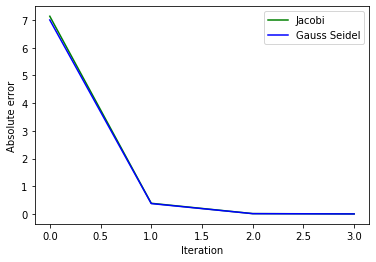


Tolerance = 1e-06
Jacobi: x = [ 3.  -2.5  7. ], iterations = 7
Gauss-Seidel: x = [ 3.  -2.5  7. ], iterations = 5


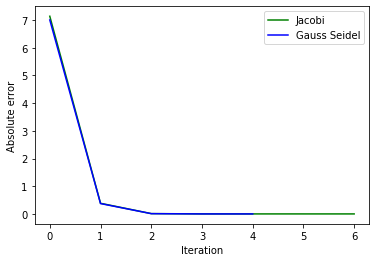


Tolerance = 1e-09
Jacobi: x = [ 3.  -2.5  7. ], iterations = 9
Gauss-Seidel: x = [ 3.  -2.5  7. ], iterations = 7


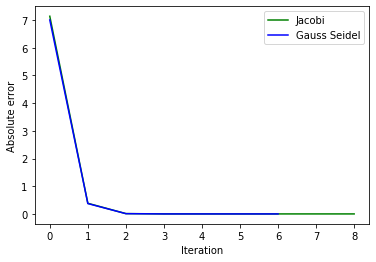

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

#Jacobi
def jacobi(A,b,x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k+1, errors
        x = x_new
    return x, max_iterations, errors

x0 = np.zeros_like(b)
tols = [1e-3, 1e-6, 1e-9]
max_iterations = 100000


#Gauss-Seidel
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k + 1, errors
        
        x = x_new
        
    return x, max_iterations, errors


for tol in tols:
    jacobi_solution, jacobi_iterations, jacobi_errors = jacobi(A, b, x0, tol, max_iterations)
    gauss_solution, gauss_iterations, gauss_errors = gauss_seidel(A, b, x0, tol, max_iterations)

    print(f"\nTolerance = {tol}")
    print(f"Jacobi: x = {jacobi_solution}, iterations = {jacobi_iterations}")
    print(f"Gauss-Seidel: x = {gauss_solution}, iterations = {gauss_iterations}")

##The number of iterations is closer when the tolerance is higher,
##however as the tolerances get smaller Jacobi takes more iterations than Gauss-Seidel

#Plot
    plt.plot(jacobi_errors, 'g-', label="Jacobi")
    plt.plot(gauss_errors, 'b-', label="Gauss Seidel")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute error")
    plt.legend()
    plt.show()